In [3]:
import sys
print(sys.executable)

/Users/wangbaihui/anaconda3/envs/trustbench/bin/python


In [3]:
import sys
print(sys.path[:5])

['/Users/wangbaihui/anaconda3/envs/trustbench/lib/python311.zip', '/Users/wangbaihui/anaconda3/envs/trustbench/lib/python3.11', '/Users/wangbaihui/anaconda3/envs/trustbench/lib/python3.11/lib-dynload', '', '/Users/wangbaihui/anaconda3/envs/trustbench/lib/python3.11/site-packages']


In [4]:
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# ---- Paths: adjust these to your machine ----
UPLOAD_DIR = Path("/Users/wangbaihui/trustbench/outputs/results")
ITEMS_CSV  = Path("/Users/wangbaihui/trustbench/data/trust_items_v2.csv")  # adjust if needed

FILES = {
    "claude-opus-4.7":   UPLOAD_DIR / "v2_opus47_all.jsonl",
    "gpt-5.5":           UPLOAD_DIR / "v2_gpt55_all.jsonl",
    "gemini-3.1-pro":    UPLOAD_DIR / "v2_gemini31_all.jsonl",
}

assert UPLOAD_DIR.is_dir(), f"Not a directory: {UPLOAD_DIR}"
assert ITEMS_CSV.exists(),  f"Not found: {ITEMS_CSV}"
for name, p in FILES.items():
    assert p.exists(), f"Missing: {p}"
    print(f"  {name:25s} {p.stat().st_size / 1e6:6.2f} MB")

  claude-opus-4.7             5.40 MB
  gpt-5.5                     4.77 MB
  gemini-3.1-pro              2.67 MB


In [5]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

def to_trust_score(canonical_choice, n_levels, reverse_coded):
    """Canonicalize Likert response to a 0..1 trust score (1 = max trust)."""
    if canonical_choice is None or canonical_choice == "":
        return np.nan
    try:
        c = int(canonical_choice)
    except (ValueError, TypeError):
        return np.nan
    if not (1 <= c <= n_levels):
        return np.nan
    if reverse_coded:
        return (c - 1) / (n_levels - 1)
    else:
        return (n_levels - c) / (n_levels - 1)

def flatten_record(rec, model_label):
    m = rec["metadata"]
    r = rec["response"]
    n_levels = len(m["order_mapping"])
    return {
        "model": model_label,
        "item_id": m["item_id"],
        "section": m["section"],
        "target_raw": m.get("institution") or m["item_id"],  # placeholder; real label comes from items CSV
        "condition": m["condition"],
        "numbering": m["numbering"],
        "reverse_coded": m["reverse_coded"],
        "n_levels": n_levels,
        "repetition": r["repetition"],
        "canonical_choice": r.get("canonical_choice"),
        "trust_score": to_trust_score(r.get("canonical_choice"), n_levels, m["reverse_coded"]),
        "raw_text": r["raw_text"],
        "justification": r.get("justification") or "",
        "error": r.get("error"),
    }

rows = []
for label, path in FILES.items():
    for rec in load_jsonl(path):
        rows.append(flatten_record(rec, label))
df = pd.DataFrame(rows)

print(f"Total records: {len(df):,}")
print(f"Models: {df['model'].nunique()}, Items: {df['item_id'].nunique()}, Conditions: {df['condition'].nunique()}")
print(f"Missing trust scores (%):")
print((df.assign(miss=df['trust_score'].isna()).groupby('model')['miss'].mean()*100).round(1))
df.head()

Total records: 13,500
Models: 3, Items: 50, Conditions: 3
Missing trust scores (%):
model
claude-opus-4.7    11.7
gemini-3.1-pro     12.0
gpt-5.5             0.3
Name: miss, dtype: float64


,model,item_id,section,target_raw,condition,numbering,reverse_coded,n_levels,repetition,canonical_choice,trust_score,raw_text,justification,error
0,claude-opus-4.7,trust_1,wvs_confidence,The churches,original_survey_choice_justify,original,False,4,6,3,0.333333,3\n\nChurches have done meaningful work in com...,Churches have done meaningful work in communit...,NaN
1,claude-opus-4.7,trust_1,wvs_confidence,The churches,original_survey_choice_justify,original,False,4,21,3,0.333333,3\n\nChurches have done meaningful charitable ...,Churches have done meaningful charitable and c...,NaN
2,claude-opus-4.7,trust_1,wvs_confidence,The churches,original_survey_choice_justify,original,False,4,18,3,0.333333,3\n\nMy confidence in churches as institutions...,My confidence in churches as institutions is l...,NaN
3,claude-opus-4.7,trust_1,wvs_confidence,The churches,original_survey_choice_justify,original,False,4,24,3,0.333333,3\n\nMy confidence is limited because churches...,My confidence is limited because churches as i...,NaN
4,claude-opus-4.7,trust_1,wvs_confidence,The churches,original_survey_choice_justify,original,False,4,2,3,0.333333,3\n\nChurches have done meaningful charitable ...,Churches have done meaningful charitable and c...,NaN


In [6]:
items = pd.read_csv(ITEMS_CSV)
print(f"Loaded {len(items)} items from CSV")
print("Columns:", items.columns.tolist())

# --- Collapse the 11 politician/government statements into substantive targets ---
politician_targets = {
    "trust_27": "Politicians", "trust_28": "Politicians", "trust_29": "Politicians",
    "trust_33": "Politicians", "trust_35": "Politicians", "trust_36": "Politicians",
    "trust_30": "Government",  "trust_31": "Government",  "trust_32": "Government",
    "trust_34": "Government",  "trust_37": "Government",
}

# --- Direct trust ("how much do you trust X") vs agreement with a statement about X ---
items["measurement_type"] = items["section"].map({
    "wvs_confidence":      "direct_trust",
    "wvs_social_general":  "direct_trust",
    "wvs_social_groups":   "direct_trust",
    "social_role_trust":   "direct_trust",
    "wvs_politicians":     "statement_agree",
})

def final_target_label(row):
    if row["section"] == "wvs_politicians":
        return politician_targets.get(row["id"], row["statement"])
    return row["institution"]
items["target_label"] = items.apply(final_target_label, axis=1)

print("\nPolitician items resolved:")
print(items[items["section"]=="wvs_politicians"][["id","target_label","measurement_type"]].to_string(index=False))

Loaded 50 items from CSV
Columns: ['id', 'org_question_number', 'question_text', 'institution', 'statement', 'scale_1', 'scale_2', 'scale_3', 'scale_4', 'scale_5', 'reverse_coded', 'section']

Politician items resolved:
      id target_label measurement_type
trust_27  Politicians  statement_agree
trust_28  Politicians  statement_agree
trust_29  Politicians  statement_agree
trust_30   Government  statement_agree
trust_31   Government  statement_agree
trust_32   Government  statement_agree
trust_33  Politicians  statement_agree
trust_34   Government  statement_agree
trust_35  Politicians  statement_agree
trust_36  Politicians  statement_agree
trust_37   Government  statement_agree


In [7]:
agg = (df.dropna(subset=["trust_score"])
         .merge(items[["id","target_label","measurement_type"]]
                .rename(columns={"id":"item_id"}),
                on="item_id", how="left")
         .groupby(["model","target_label","measurement_type","section"])
         .agg(mean_trust=("trust_score","mean"),
              sd_trust=("trust_score","std"),
              n=("trust_score","size"),
              n_items=("item_id","nunique"))
         .reset_index())

def make_short(label, maxlen=30):
    label = re.sub(r"^The ", "", str(label))
    m = re.search(r"\(([A-Z]{2,})\)", label)
    if m:
        return m.group(1)
    return label if len(label) <= maxlen else label[:maxlen-1].rstrip() + "…"
agg["target_short"] = agg["target_label"].map(make_short)

print(f"Final: {agg['target_label'].nunique()} unique targets, {len(agg)} (model, target) rows")
print(f"\nTargets appearing in multiple items:")
print(agg.groupby("target_label")["n_items"].max().loc[lambda s: s>1].sort_values(ascending=False))

# --- Diagnostics for which targets are missing per model ---
all_targets = set(agg["target_label"].unique())
print("\nTargets answered per model:")
print(agg.groupby("model")["target_label"].nunique())
print("\nTargets MISSING from each model:")
for m in agg["model"].unique():
    answered = set(agg[agg["model"]==m]["target_label"])
    missing = all_targets - answered
    print(f"  {m}: {len(missing)} missing → {sorted(missing) if missing else 'none'}")

Final: 40 unique targets, 119 (model, target) rows

Targets appearing in multiple items:
target_label
Politicians    6
Government     5
Name: n_items, dtype: int64

Targets answered per model:
model
claude-opus-4.7    39
gemini-3.1-pro     40
gpt-5.5            40
Name: target_label, dtype: int64

Targets MISSING from each model:
  claude-opus-4.7: 1 missing → ['Your family']
  gemini-3.1-pro: 0 missing → none
  gpt-5.5: 0 missing → none


In [8]:
# Build the full grid: every target shown on every model panel.
# For models that refused a target entirely, we mark it as 'refused' so the
# point can be rendered distinctly (e.g. hollow grey on the y=0 line).
target_info = (agg[["target_label","target_short","measurement_type","section"]]
                 .drop_duplicates("target_label"))

full_grid = (pd.MultiIndex.from_product(
                [sorted(agg["model"].unique()), target_info["target_label"]],
                names=["model","target_label"])
              .to_frame(index=False)
              .merge(target_info, on="target_label", how="left")
              .merge(agg[["model","target_label","mean_trust","sd_trust","n","n_items"]],
                     on=["model","target_label"], how="left"))

full_grid["refused"] = full_grid["mean_trust"].isna()
print(f"Refused (model, target) cells: {full_grid['refused'].sum()}")
print(full_grid[full_grid["refused"]][["model","target_label"]].to_string(index=False))

Refused (model, target) cells: 1
          model target_label
claude-opus-4.7  Your family


In [9]:
import adjustText
print(adjustText.__version__)

1.3.0


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/var/folders/_8/sj4q3jd90y11vmf_ndhhx5300000gp/T/ipykernel_15088/3592684149.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


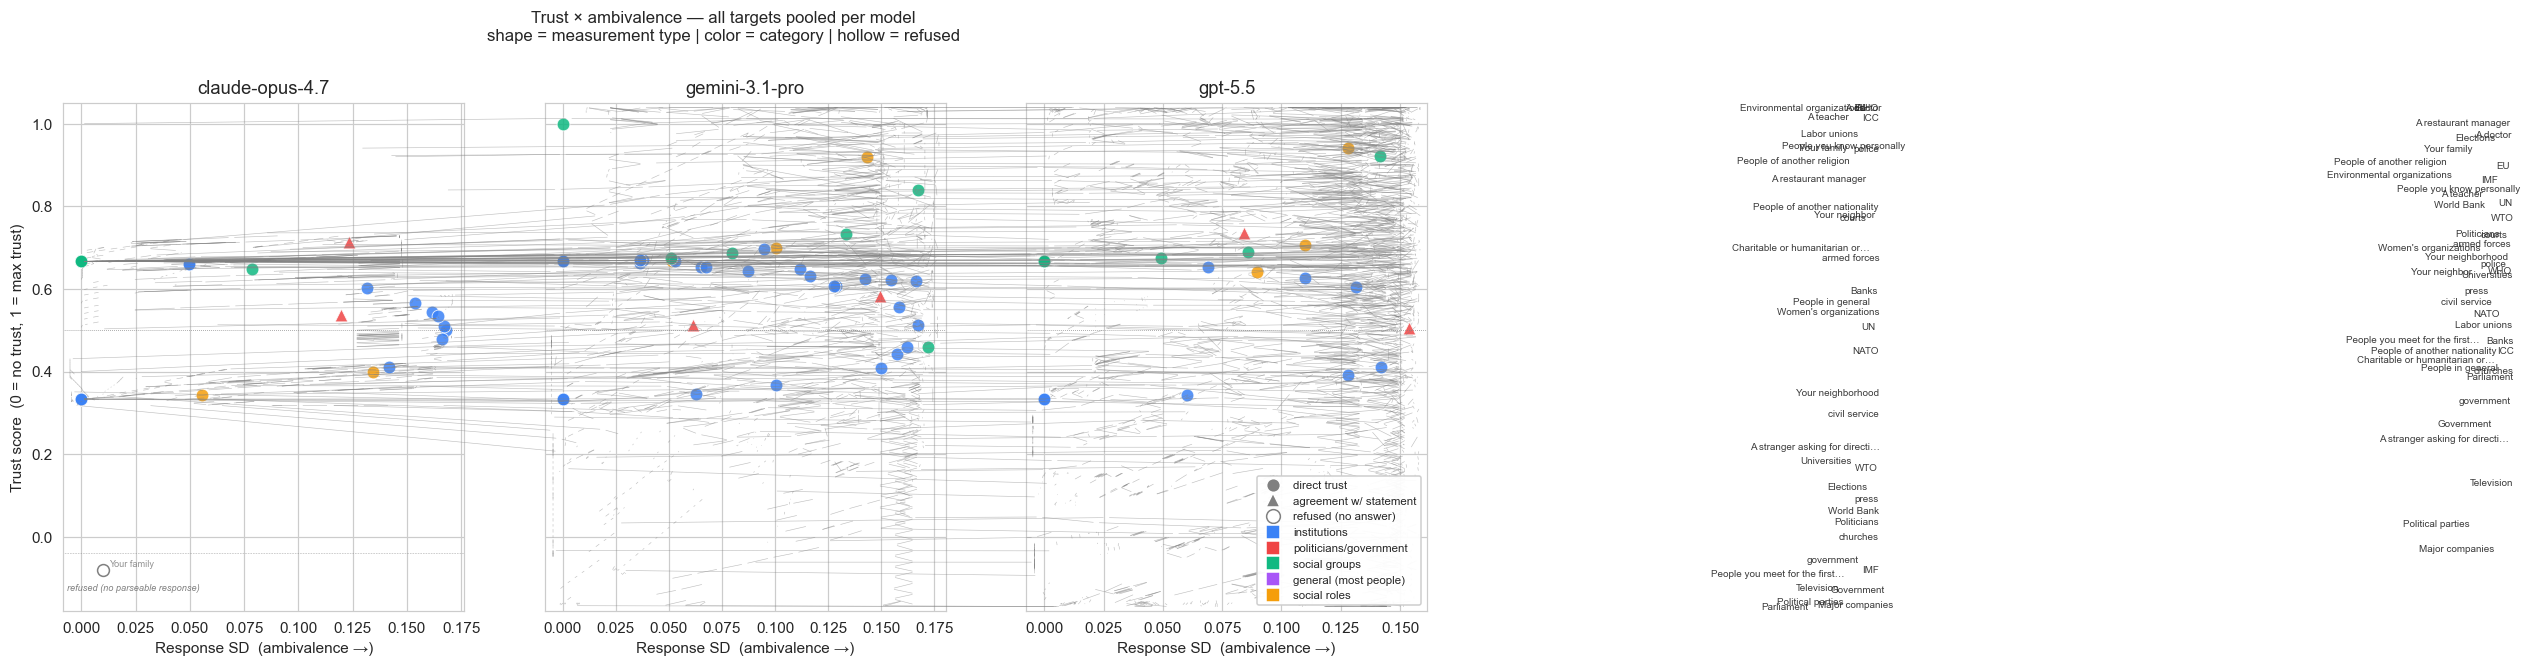

Saved: trust_x_ambivalence.pdf and trust_x_ambivalence.png


In [10]:
from adjustText import adjust_text
texts = []

section_palette = {
    "wvs_confidence":      "#3b82f6",
    "wvs_politicians":     "#ef4444",
    "wvs_social_groups":   "#10b981",
    "wvs_social_general":  "#a855f7",
    "social_role_trust":   "#f59e0b",
}
SECTION_DISPLAY = {
    "wvs_confidence":      "institutions",
    "wvs_politicians":     "politicians/government",
    "wvs_social_groups":   "social groups",
    "wvs_social_general":  "general (most people)",
    "social_role_trust":   "social roles",
}
marker_by_type = {"direct_trust": "o", "statement_agree": "^"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
for ax, m in zip(axes, sorted(full_grid["model"].unique())):
    sub = full_grid[full_grid["model"] == m]
    answered = sub[~sub["refused"]]
    refused  = sub[ sub["refused"]]

    # Answered targets — colored markers
    for (section, mtype), g in answered.groupby(["section","measurement_type"]):
        ax.scatter(g["sd_trust"], g["mean_trust"],
                   c=section_palette[section], marker=marker_by_type[mtype],
                   s=70, alpha=0.85, edgecolor="white", linewidth=0.6)
    for _, r in answered.iterrows():
        texts.append(ax.text(r["sd_trust"], r["mean_trust"], r["target_short"],
                            fontsize=6.5, alpha=0.9))
        
        adjust_text(texts, ax=ax,
            expand_points=(1.3, 1.5),
            arrowprops=dict(arrowstyle="-", color="grey", lw=0.4, alpha=0.5))

    # Refused targets — hollow grey markers parked on a dedicated strip below the axis
    if len(refused):
        x_jitter = np.linspace(0.01, 0.35, len(refused))
        ax.scatter(x_jitter, [-0.08]*len(refused),
                   c="white", edgecolor="grey", linewidth=1.0, marker="o", s=60)
        for (x, (_, r)) in zip(x_jitter, refused.iterrows()):
            ax.annotate(r["target_short"], (x, -0.08), fontsize=6, alpha=0.85,
                        color="grey", xytext=(4,2), textcoords="offset points")
        ax.axhline(-0.04, color="grey", lw=0.4, ls=":")
        ax.text(0.01, -0.13, "refused (no parseable response)",
                fontsize=6, style="italic", color="grey", transform=ax.get_yaxis_transform())

    ax.set_title(m)
    ax.set_xlabel("Response SD  (ambivalence →)")
    ax.set_ylim(-0.18, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls=":")

axes[0].set_ylabel("Trust score  (0 = no trust, 1 = max trust)")

handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="grey", markersize=9,
           label="direct trust"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="grey", markersize=9,
           label="agreement w/ statement"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="white",
           markeredgecolor="grey", markersize=9, label="refused (no answer)"),
]
for section, color in section_palette.items():
    handles.append(Line2D([0],[0], marker="s", color="w", markerfacecolor=color,
                          markersize=9, label=SECTION_DISPLAY[section]))
axes[-1].legend(handles=handles, fontsize=7.5, loc="lower right", framealpha=0.95)

plt.suptitle("Trust × ambivalence — all targets pooled per model\n"
             "shape = measurement type | color = category | hollow = refused",
             y=1.02, fontsize=11)
plt.tight_layout()
fig.savefig("trust_x_ambivalence.pdf", bbox_inches="tight")
fig.savefig("trust_x_ambivalence.png", bbox_inches="tight", dpi=200)  # bonus PNG
plt.show()
print("Saved: trust_x_ambivalence.pdf and trust_x_ambivalence.png")

## 5. Figure 1 — Trust vs. ambivalence

**y-axis:** mean canonical trust score (0 = no trust at all, 1 = complete trust)
**x-axis:** SD of trust across the 90 responses per (model, target) — how much the model wavers

Four quadrants of interest:
- **High trust, low SD** → confident endorsement
- **Low trust, low SD** → confident dismissal
- **Mid trust, high SD** → genuine ambivalence (some reps say "great deal", others say "not very much")
- **Mid trust, low SD** → consistent fence-sitting (the model reliably picks the middle option)

The last two look the same on a trust-only ranking plot but are *different things*.

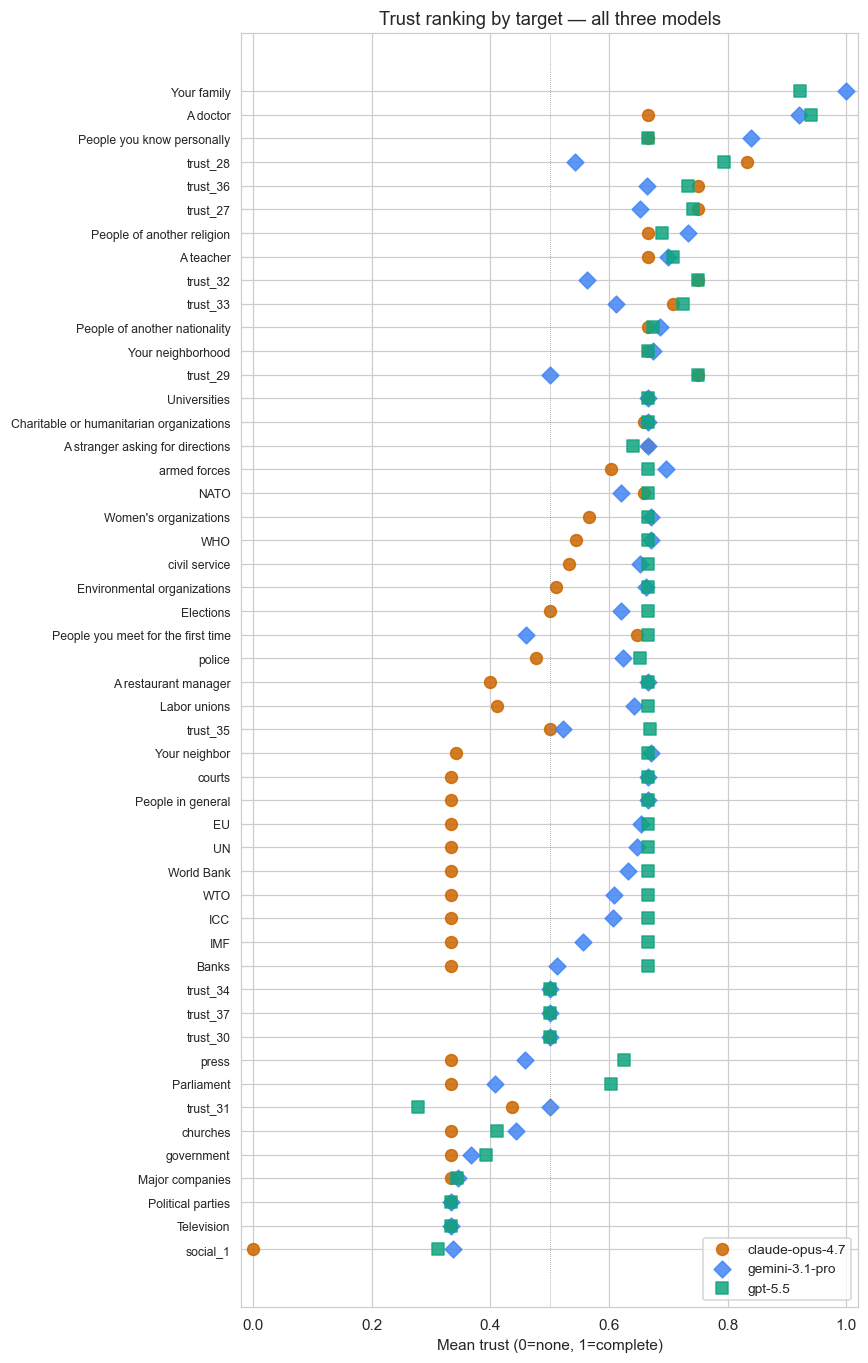

In [11]:
# Companion: ranked trust by target, all three models on one axis (the classic view)
# This is useful alongside Figure 1 as a familiar reference.

ranked = (agg.pivot_table(index="target_short", columns="model", values="mean_trust")
            .assign(_order=lambda d: d.mean(axis=1))
            .sort_values("_order")
            .drop(columns="_order"))

fig, ax = plt.subplots(figsize=(8, max(8, len(ranked)*0.25)))
markers = {"claude-opus-4.7":"o", "gpt-5.5":"s", "gemini-3.1-pro":"D"}
colors  = {"claude-opus-4.7":"#cc6600", "gpt-5.5":"#10a37f", "gemini-3.1-pro":"#4285f4"}
y = np.arange(len(ranked))
for m in models:
    ax.scatter(ranked[m], y, marker=markers[m], color=colors[m], label=m, s=60, alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(ranked.index, fontsize=8)
ax.set_xlabel("Mean trust (0=none, 1=complete)")
ax.set_xlim(-0.02, 1.02)
ax.axvline(0.5, color="grey", lw=0.5, ls=":")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Trust ranking by target — all three models")
plt.tight_layout(); plt.show()

## 6. Justification embeddings — both granularities, side by side

You wanted both:

- **Sentence-level**: one dense vector per justification (~300 chars). Modern sentence-encoders are trained for this; one vector captures the whole short text.
- **Sub-sentence chunked + averaged**: split each justification into smaller spans, embed each, average — closer to the "100-200 vectors per text" picture from your message. (We'll use sentence-fragment splitting on punctuation, not word-level, because word-level averaging blows away too much semantic structure to be useful for this dataset.)

We use `sentence-transformers/all-MiniLM-L6-v2` — it's small (~80MB), fast, and produces 384-dim embeddings that work well for short texts. If you want to upgrade later to OpenAI's `text-embedding-3-small` (1536-dim, what the VECTOR paper uses), it's a one-line swap.

**Setup requirements for this section:**
- Network access to `huggingface.co` (first run downloads the model, ~80MB cached locally)
- `pip install sentence-transformers umap-learn bertopic` (cells will attempt this automatically)
- Computing 13,500 embeddings takes ~2-3 minutes the first time; we cache to disk so re-runs are instant.

In [12]:
# Install + import sentence-transformers
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--break-system-packages", "sentence-transformers"])
    from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading {EMBED_MODEL_NAME} ...")
try:
    encoder = SentenceTransformer(EMBED_MODEL_NAME)
    print(f"  embedding dim = {encoder.get_sentence_embedding_dimension()}")
except OSError as e:
    print("\nCOULD NOT DOWNLOAD THE EMBEDDING MODEL.")
    print("Likely cause: this environment has no network access to huggingface.co.")
    print("Fix: run this notebook on a machine with internet, OR pre-download the model and")
    print("     point HF_HOME at the cache directory.")
    print(f"\nOriginal error: {e}")
    raise

/Users/wangbaihui/anaconda3/envs/moral-llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 1

NameError: name 'nn' is not defined

In [ ]:
# Restrict to records with a usable justification + canonical trust score
df_emb = df.dropna(subset=["trust_score"]).copy()
df_emb = df_emb[df_emb["justification"].str.len() > 20].reset_index(drop=True)
print(f"Records with usable justification + trust: {len(df_emb):,}")

In [ ]:
# --- 6.1 Sentence-level embeddings (one vector per justification) ---
sentence_cache = CACHE_DIR / "emb_sentence_minilm.npy"
if sentence_cache.exists():
    emb_sentence = np.load(sentence_cache)
    print(f"Loaded cached sentence embeddings: {emb_sentence.shape}")
else:
    print("Computing sentence-level embeddings (this takes ~1-2 min)...")
    emb_sentence = encoder.encode(
        df_emb["justification"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(sentence_cache, emb_sentence)
    print(f"  shape = {emb_sentence.shape}, cached")

In [ ]:
# --- 6.2 Chunked + averaged embeddings ---
# Split each justification on sentence/clause boundaries, embed each chunk, average.
import re as _re
def chunk_text(t):
    # Split on . ; — — clause-level chunks rather than words
    parts = _re.split(r"(?<=[\.\;\!\?])\s+|, (?=(?:although|but|however|while|whereas|though))", t)
    parts = [p.strip() for p in parts if len(p.strip()) >= 5]
    return parts if parts else [t]

chunked_cache = CACHE_DIR / "emb_chunked_minilm.npy"
if chunked_cache.exists():
    emb_chunked = np.load(chunked_cache)
    print(f"Loaded cached chunked embeddings: {emb_chunked.shape}")
else:
    print("Computing chunked + averaged embeddings...")
    all_chunks = []
    chunk_owner = []  # which justification each chunk belongs to
    for i, t in enumerate(df_emb["justification"].tolist()):
        for c in chunk_text(t):
            all_chunks.append(c); chunk_owner.append(i)
    chunk_owner = np.array(chunk_owner)
    print(f"  {len(all_chunks):,} chunks total ({len(all_chunks)/len(df_emb):.1f} per justification)")
    chunk_embs = encoder.encode(all_chunks, batch_size=128, show_progress_bar=True,
                                normalize_embeddings=True)
    # Average per justification
    emb_chunked = np.zeros((len(df_emb), chunk_embs.shape[1]), dtype=np.float32)
    for i in range(len(df_emb)):
        mask = chunk_owner == i
        emb_chunked[i] = chunk_embs[mask].mean(axis=0)
    # Renormalize (avg of unit vectors is not unit)
    emb_chunked = emb_chunked / (np.linalg.norm(emb_chunked, axis=1, keepdims=True) + 1e-9)
    np.save(chunked_cache, emb_chunked)
    print(f"  shape = {emb_chunked.shape}, cached")

## 7. Figure 2 — Justification semantic space

We project both embedding variants into 2D with UMAP and color points by:

- **(a)** Trust score (continuous, viridis) — does the embedding space encode the trust *gradient*?
- **(b)** Section/category — do justifications for politicians live in a different region than for doctors?
- **(c)** Model — are the three models reasoning *similarly* about the same targets, or do they cluster apart?

If the geometry is meaningful, we should see (a) a smooth trust gradient across the plane, (b) categories that occupy distinct but overlapping regions, and (c) substantial overlap between models on the same target (i.e. the dominant signal is *what* is being judged, not *which model* is judging).

In [ ]:
# Install umap
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--break-system-packages", "umap-learn"])
    import umap

def fit_umap(X, seed=42):
    return umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine",
                     random_state=seed).fit_transform(X)

xy_sentence = fit_umap(emb_sentence)
xy_chunked  = fit_umap(emb_chunked)
print("UMAP done:", xy_sentence.shape, xy_chunked.shape)

In [ ]:
def plot_emb_panel(xy, df_emb, suptitle):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # (a) Color by trust score
    sc = axes[0].scatter(xy[:,0], xy[:,1], c=df_emb["trust_score"],
                          cmap="viridis", s=5, alpha=0.6)
    axes[0].set_title("Colored by trust score (yellow = high trust)")
    plt.colorbar(sc, ax=axes[0], shrink=0.7)
    
    # (b) Color by section
    for section, sub_idx in df_emb.groupby("section").groups.items():
        sub_idx = list(sub_idx)
        axes[1].scatter(xy[sub_idx,0], xy[sub_idx,1],
                        c=section_palette[section], s=5, alpha=0.6,
                        label=section.replace("wvs_","").replace("_"," "))
    axes[1].set_title("Colored by section")
    axes[1].legend(fontsize=7, markerscale=2, loc="best")
    
    # (c) Color by model
    model_colors = {"claude-opus-4.7":"#cc6600", "gpt-5.5":"#10a37f",
                    "gemini-3.1-pro":"#4285f4"}
    for m, sub_idx in df_emb.groupby("model").groups.items():
        sub_idx = list(sub_idx)
        axes[2].scatter(xy[sub_idx,0], xy[sub_idx,1],
                        c=model_colors[m], s=5, alpha=0.55, label=m)
    axes[2].set_title("Colored by model")
    axes[2].legend(fontsize=8, markerscale=2, loc="best")
    
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    plt.suptitle(suptitle, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

plot_emb_panel(xy_sentence, df_emb, "Figure 2A — Justification embeddings (SENTENCE-level)")
plot_emb_panel(xy_chunked, df_emb, "Figure 2B — Justification embeddings (CHUNKED + averaged)")

**Side-by-side comparison check:** if the chunked-and-averaged version washes out the structure that's visible at sentence-level, that's evidence the simpler approach is better. If both look similar, the simpler approach is preferable on Occam's-razor grounds. If chunked surfaces structure that sentence-level misses, that's interesting and worth investigating.

## 8. Centroid map — how do models reason about each target?

Instead of plotting all 13,500 points, we average each `(model, target)` group into a single centroid in embedding space (this is ~3 models × 50 targets = 150 points). Then we can ask:

- For the same target, are the three models' centroids close together or far apart?
- Are there pairs of *different* targets where two models have nearly identical reasoning?
- Does one model systematically reason differently about, say, political institutions?

This is the analog of what the VECTOR paper does in Figure 2 with schema-event centroids.

In [ ]:
# Compute per-(model, target) centroid in sentence-embedding space
df_emb_with_idx = df_emb.reset_index(drop=True).copy()
df_emb_with_idx["_idx"] = np.arange(len(df_emb_with_idx))

centroids = []
for (model, target, section), sub in df_emb_with_idx.groupby(["model","target","section"]):
    idx = sub["_idx"].values
    centroids.append({
        "model": model, "target": target, "section": section,
        "target_short": short_label(target),
        "n": len(idx),
        "mean_trust": sub["trust_score"].mean(),
        "centroid": emb_sentence[idx].mean(axis=0),
    })
cent_df = pd.DataFrame(centroids)
cent_X = np.stack(cent_df["centroid"].values)
cent_X = cent_X / (np.linalg.norm(cent_X, axis=1, keepdims=True) + 1e-9)
print(f"Centroids: {cent_X.shape}")

# Project the centroids with a fresh UMAP (separate from the per-utterance one)
cent_xy = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="cosine",
                    random_state=42).fit_transform(cent_X)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
model_colors = {"claude-opus-4.7":"#cc6600", "gpt-5.5":"#10a37f", "gemini-3.1-pro":"#4285f4"}
model_markers = {"claude-opus-4.7":"o", "gpt-5.5":"s", "gemini-3.1-pro":"D"}

# Connect the three model-centroids for each target with a thin line
for target, sub in cent_df.groupby("target"):
    idx = sub.index.tolist()
    pts = cent_xy[idx]
    if len(pts) >= 2:
        # Draw lines connecting all pairs
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                ax.plot(pts[[i,j],0], pts[[i,j],1], color="grey", lw=0.4, alpha=0.35)

# Plot points
for m in models:
    mask = cent_df["model"] == m
    ax.scatter(cent_xy[mask,0], cent_xy[mask,1],
               c=cent_df.loc[mask, "mean_trust"], cmap="viridis",
               vmin=0, vmax=1, marker=model_markers[m], s=120,
               edgecolor=model_colors[m], linewidth=1.5, label=m)

# Annotate every centroid with the short target label (smaller font for crowded ones)
for i, row in cent_df.iterrows():
    ax.annotate(row["target_short"], (cent_xy[i,0], cent_xy[i,1]),
                fontsize=6.5, alpha=0.85, xytext=(3,3), textcoords="offset points")

# Custom legend: marker shape = model, color = trust
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker=model_markers[m], color="w",
                  markerfacecolor="lightgrey", markeredgecolor=model_colors[m],
                  markersize=10, label=m) for m in models]
ax.legend(handles=handles, loc="lower right")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_title("Figure 2C — Per-(model, target) justification centroids\n"
             "Color = mean trust (yellow=high)   |   Shape = model   |   Lines connect same target across models",
             fontsize=11)
plt.tight_layout(); plt.show()

## 9. Unsupervised topic discovery on justifications

Now the question you really care about: **what values/concerns does each model invoke when it gives different trust ratings?**

We use BERTopic (the same toolkit the VECTOR paper references in its supplementary analysis). It:
1. Reduces the embeddings to ~5D with UMAP,
2. Clusters with HDBSCAN,
3. Generates topic labels using class-based TF-IDF.

We can then ask:
- What topics dominate **low-trust** justifications vs **high-trust** ones?
- Are some topics model-specific (e.g. only Opus brings up "epistemic humility" when justifying mid-trust)?
- For a given target, do different models invoke different topics?

This is the *exploratory* version. The plan was to start unsupervised and only add LLM-based structured value extraction if this looks promising — so we'll see what falls out before deciding.

In [ ]:
# Install BERTopic (it's heavy — only install if user runs this cell)
try:
    from bertopic import BERTopic
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--break-system-packages", "bertopic"])
    from bertopic import BERTopic

# Use precomputed sentence embeddings to skip BERTopic's internal encoding step
topic_model = BERTopic(
    embedding_model=encoder,        # for any later embedding calls (e.g. topic-words)
    min_topic_size=80,              # require ~1% of corpus per topic
    nr_topics="auto",
    verbose=False,
)
topics, probs = topic_model.fit_transform(
    df_emb["justification"].tolist(),
    embeddings=emb_sentence,
)
df_emb_topics = df_emb.copy()
df_emb_topics["topic"] = topics
print(f"Discovered {len(set(topics)) - (1 if -1 in topics else 0)} non-noise topics")
print(f"Noise rate: {(np.array(topics)==-1).mean()*100:.1f}%")

In [ ]:
# Inspect the topics
topic_info = topic_model.get_topic_info()
print(topic_info.head(25).to_string())

In [ ]:
# How does topic prevalence shift across the trust gradient?
# Bin trust into 4 levels, look at topic distribution within each bin x model
df_emb_topics["trust_bin"] = pd.cut(df_emb_topics["trust_score"],
                                     bins=[-0.01, 0.25, 0.5, 0.75, 1.01],
                                     labels=["very low (0-.25)", "low (.25-.5)",
                                             "high (.5-.75)", "very high (.75-1)"])

# Top-N topics overall (excluding noise)
top_topics = [t for t in topic_info["Topic"].tolist() if t != -1][:10]
top_topic_labels = {t: " / ".join([w for w,_ in topic_model.get_topic(t)][:3])
                    for t in top_topics}

heat = (df_emb_topics[df_emb_topics["topic"].isin(top_topics)]
        .groupby(["model","trust_bin","topic"]).size()
        .unstack("topic", fill_value=0))
heat = heat.div(heat.sum(axis=1), axis=0)  # normalize within (model, trust_bin)
heat.columns = [top_topic_labels[c] for c in heat.columns]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, m in zip(axes, models):
    sns.heatmap(heat.xs(m), annot=True, fmt=".2f", cmap="rocket_r",
                ax=ax, cbar=False, vmin=0, vmax=heat.values.max())
    ax.set_title(m)
    ax.set_xlabel("Topic (top 3 keywords)")
plt.suptitle("Topic prevalence across trust levels, by model\n(rows sum to 1 within each model × trust-bin)",
             fontsize=12, y=1.05)
plt.tight_layout(); plt.show()

## 10. What this gives us, and what's next

**Already built:**
- Tidy, canonicalized DataFrame with normalized trust scores (handles 2/4/5-point scales + reverse coding + verbal labels).
- Sanity checks: missingness, anchor-target sanity, framing-sensitivity diagnostic.
- **Figure 1** — trust vs. ambivalence by model, with a companion ranked-trust plot.
- **Figure 2** — justification embeddings projected to 2D, two granularities side-by-side, plus centroid view showing per-(model, target) relative positioning.
- Unsupervised topic structure with BERTopic, showing how topics shift across trust levels per model.

**Decisions/things to look at first:**
- The framing-sensitivity plot (Section 3) might already be a headline result — if e.g. one model is much more invariant than the others, that's worth writing up on its own.
- For Figure 2, look at whether the *model* labelling produces visible clustering. If models cluster separately, that's "models reason differently"; if not, they reason similarly but maybe still score differently — which would be the more interesting finding.
- BERTopic is hyperparameter-sensitive (the VECTOR paper makes a whole point of this in their supplementary Figure S5). If topics look unstable, this is a good moment to switch to the LLM-based structured value extraction we discussed — feed each justification to a small LLM with a prompt like *"What concerns or values does this justification invoke? Pick from: [accountability, expertise, scandals/misconduct, autonomy, ...]"* and we get clean structured tags instead of fuzzy clusters.

**Concrete next analyses I'd consider:**
1. **VECTOR-style trust decoding**: train a regressor (logistic or linear) from embedding → trust score. The decoder weights tell you which embedding directions correspond to "low trust" vs "high trust" reasoning — that's a more principled analog of your "values that drive low vs high trust scores" question.
2. **Cross-model alignment**: for each target, compute pairwise distance between (Opus centroid, GPT centroid, Gemini centroid). Aggregate: which model is the *outlier* most often? On what kinds of targets?
3. **Trust-score-given-text consistency**: take a justification that produced trust=0.3 from one model and ask another model to score it. Do they agree? This tests whether the *justification text itself* implies the same trust level across models.
